# Helical acquisition and reconstruction testing

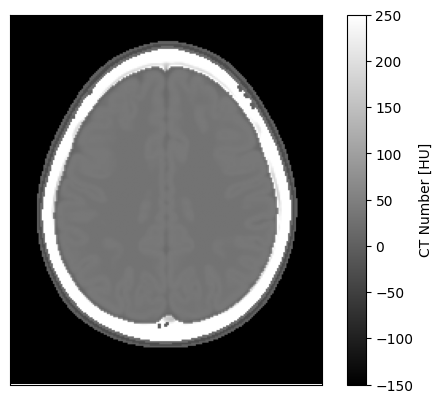

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from insilicoICH.ground_truth_definition.phantoms import NIHPD_Head

from utils import ctshow

nihpd_dir = Path('../phantom_dir/NIHPD_Head_Phantom')
nihpd = NIHPD_Head(nihpd_dir, age=11.5)

im = ctshow(nihpd.get_CT_number_phantom()[80])
plt.colorbar(im, label='CT Number [HU]')

In [2]:
from insilicoICH.image_acquisition import Scanner

nihpd.patient_name = 'helical_test'
scanner = Scanner(nihpd)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing helical_test/phantoms/0/0_ncat_ad


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

In [ ]:
import gecatsim as xc
from gecatsim.reconstruction.pyfiles import recon

##--------- Initialize 
ct = xc.CatSim("../src/insilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/insilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/insilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/insilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/insilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

##--------- Make changes to parameters (optional)
# ct.phantom.filename = 'water20.ppm'
#ct.phantom.filename = 'CTDI_16cm_WaterAirPEBoneChambers.ppm'
ct.phantom.filename = '/home/jayse.weaver/repositories/InSilicoICH/notebooks/helical_test/phantoms/0/0.json'
ct.resultsName = "test_Helical"

print(ct.protocol.startZ)
ct.protocol.startZ = 0
print(ct.protocol.startZ)

#scanner.scout_view(startZ=0)

##--------- Run simulation
ct.run_all()  # run the scans defined by protocol.scanTypes


if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

-12.79
0
Airscan
Offset scan
Phantom scan


  0%|          | 0/9000 [00:00<?, ?it/s]

In [ ]:
cfg.recon.sliceThickness = 1
print(cfg.recon.sliceThickness)

cfg.do_Recon = 1
cfg.waitForKeypress = 0
recon.recon(cfg)